In [1]:
# Importing libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fontTools.ufoLib import deprecatedFontInfoAttributesVersion2
from matplotlib.image import imread
import seaborn as sns
import random
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow. keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPool2D

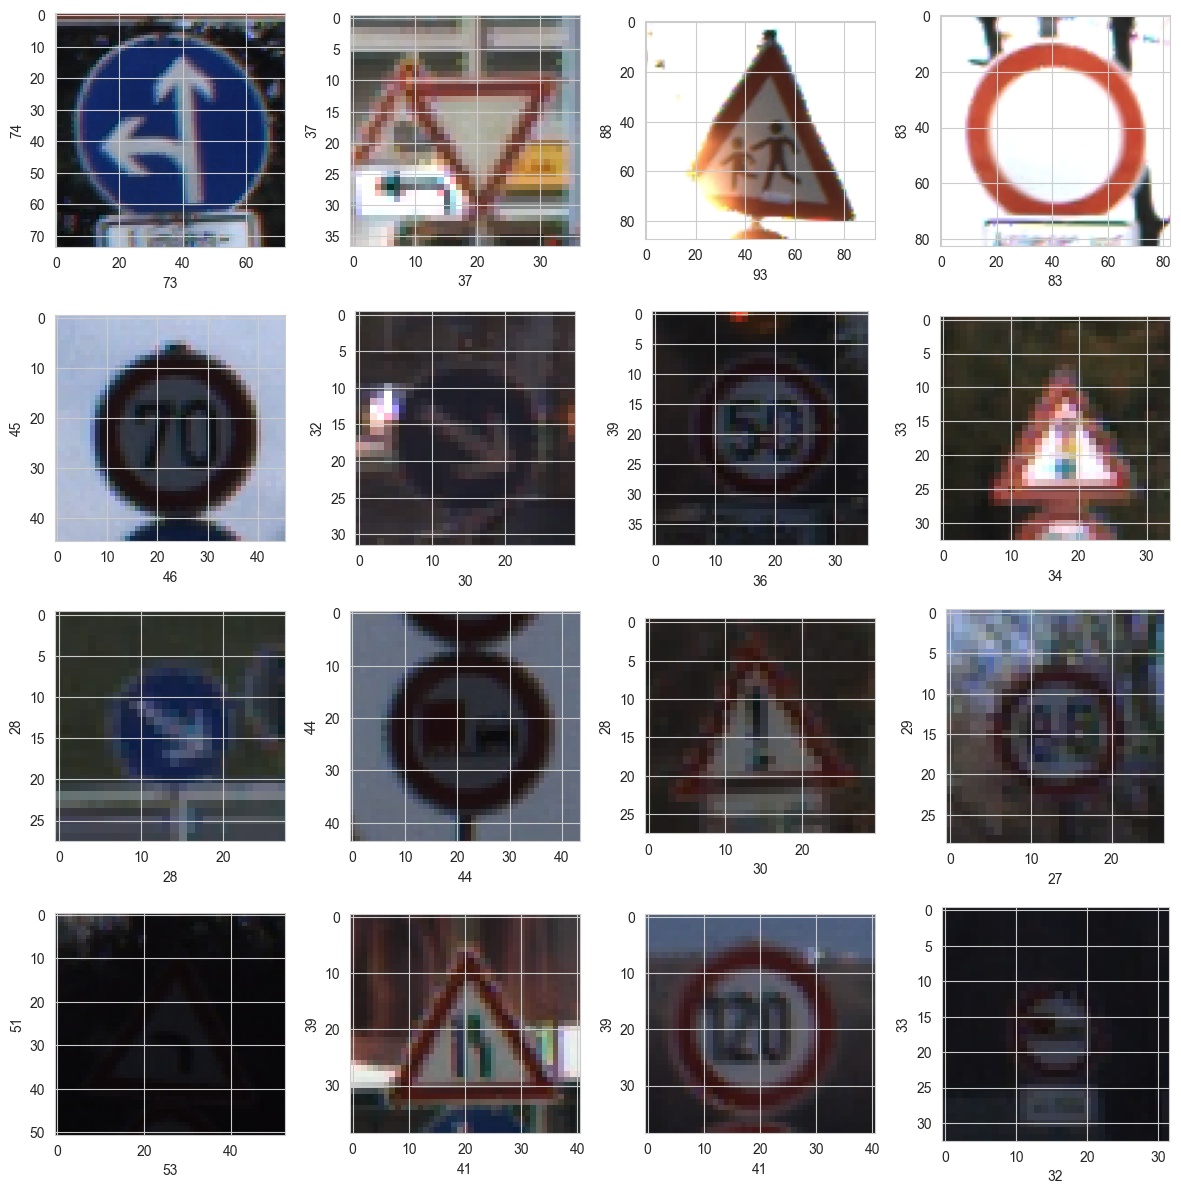

In [2]:
# Plotting 12 images to check dataset
plt.figure(figsize=(12,12))
path = "Dataset/Test"
for i in range(1,17):
    plt.subplot(4,4,i)
    plt.tight_layout()
    rand_img = imread(path + '/' + random.choice(sorted(os.listdir(path))))
    plt.imshow(rand_img)
    plt.xlabel(rand_img.shape[1], fontsize=10) # width
    plt.ylabel(rand_img.shape[0], fontsize=10) # height

In [3]:
# As size of images are different we have to make them equal so we will take mean of dimanesions
dim1 = []
dim2 = []

for i in range(0,43):
    labels = 'Dataset/Train' + '/{0}'.format(i)
    image_path = os.listdir(labels)
    for x in image_path:
        img = imread(labels + '/' + x)
        dim1.append (img.shape[0])
        dim2.append (img.shape [1])

In [4]:
print("Dimension 1 Mean : ", np.mean(dim1), " Dimension 2 Mean : ", np.mean(dim2))

Dimension 1 Mean :  50.328929582493814  Dimension 2 Mean :  50.83587951745773


In [5]:
images = []
label_id = []

for i in range(43):
    labels = 'Dataset/Train' + '/{0}'.format(i)
    image_path = os.listdir(labels)
    for x in image_path:
        img = Image.open(labels + '/' + x)
        img = img.resize((50,50))
        img = np.array(img)
        images.append(img)
        label_id.append(i)

In [6]:
images = np.array(images)
images = images/255

In [7]:
label_id = np.array(label_id)
print(label_id.shape)
print(images.shape)

(39209,)
(39209, 50, 50, 3)


In [8]:
label_counts = pd.DataFrame(label_id).value_counts()
label_counts.head()

0 
2     2250
1     2220
13    2160
12    2100
38    2070
Name: count, dtype: int64

In [9]:
x_train, x_val, y_train, y_val = train_test_split(images, label_id, test_size=0.2, random_state=42)

In [10]:
y_train_cat = to_categorical(y_train)
y_val_cat = to_categorical(y_val)

In [11]:
model = Sequential()

model.add(Conv2D(filters=64, kernel_size=(3,3), input_shape=x_train.shape[1:], activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.5))

model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.5))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(43, activation='softmax'))

/Users/aaravgoyal/Library/Python/3.12/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 50, 50, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 23, 23, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7744)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       991,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,035,627 (3.95 MB)

 Trainable params: 1,035,627 (3.95 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.fit(x_train, y_train, epochs = 50, batch_size = 128, validation_data = (x_val, y_val), verbose = 2)

Epoch 1/50
246/246 - 25s - 103ms/step - accuracy: 0.2924 - loss: 2.5674 - val_accuracy: 0.6251 - val_loss: 1.4276
Epoch 2/50
246/246 - 26s - 108ms/step - accuracy: 0.5673 - loss: 1.3657 - val_accuracy: 0.8372 - val_loss: 0.6704
Epoch 3/50
246/246 - 23s - 95ms/step - accuracy: 0.6859 - loss: 0.9650 - val_accuracy: 0.9102 - val_loss: 0.4534
Epoch 4/50
246/246 - 26s - 107ms/step - accuracy: 0.7453 - loss: 0.7773 - val_accuracy: 0.9404 - val_loss: 0.2987
Epoch 5/50
246/246 - 25s - 103ms/step - accuracy: 0.7800 - loss: 0.6609 - val_accuracy: 0.9578 - val_loss: 0.2347
Epoch 6/50
246/246 - 26s - 106ms/step - accuracy: 0.8063 - loss: 0.5797 - val_accuracy: 0.9649 - val_loss: 0.1865
Epoch 7/50
246/246 - 25s - 102ms/step - accuracy: 0.8238 - loss: 0.5312 - val_accuracy: 0.9677 - val_loss: 0.1602
Epoch 8/50
246/246 - 25s - 103ms/step - accuracy: 0.8377 - loss: 0.4767 - val_accuracy: 0.9755 - val_loss: 0.1461
Epoch 9/50
246/246 - 26s - 105ms/step - accuracy: 0.8532 - loss: 0.4361 - val_accuracy: 0

<Axes: >

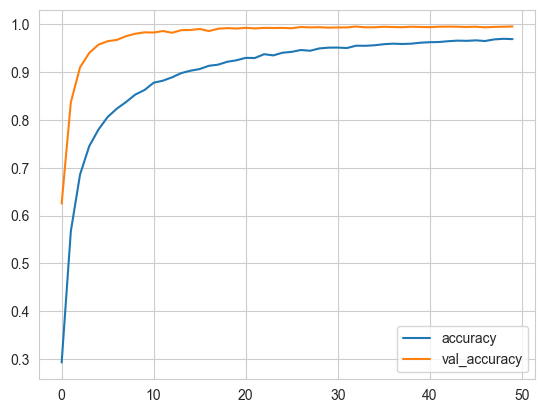

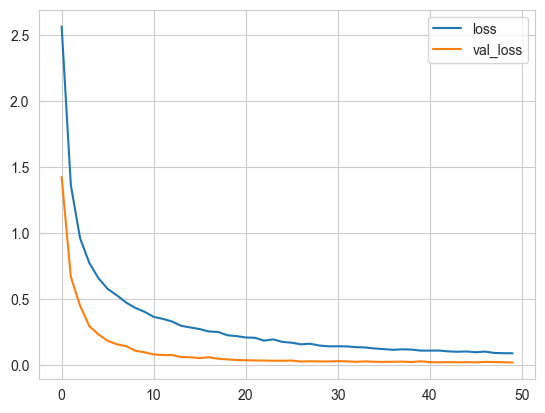

In [14]:
evaluation = pd.DataFrame(model.history.history)
evaluation[['accuracy', 'val_accuracy']].plot()
evaluation[['loss', 'val_loss']].plot()

In [15]:
test_path = "Dataset/Test"
!rm Dataset/Test/GT-Final_Test.csv

from PIL import Image

def scaling(test_images, test_path):
    images = []
    image_path = test_images
    for x in image_path:
        img = Image.open(test_path + '/' + x)
        img = img.resize((50,50))
        img = np.array(img)
        images.append(img)

    images = np.array(images)
    images = images/255
    return images

In [16]:
test_images = scaling(sorted(os.listdir(test_path)), test_path)

In [17]:
test = pd.read_csv("Dataset/Test.csv")
y_test = test["ClassId"].values
y_test

array([16,  1, 38, ...,  6,  7, 10])

In [18]:
y_pred= model.predict(test_images)
y_pred

395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


array([[2.97580298e-25, 2.19239781e-23, 1.44871310e-27, ...,
        1.46966498e-19, 4.60569501e-31, 1.70644349e-17],
       [1.45383261e-14, 1.00000000e+00, 4.98920327e-09, ...,
        2.06397191e-30, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [2.83199057e-07, 1.17961885e-04, 7.24003348e-06, ...,
        8.68666102e-05, 1.16540114e-05, 1.32420580e-04],
       [4.21550680e-14, 4.88964069e-08, 1.98023393e-08, ...,
        3.53288926e-12, 5.74850217e-21, 5.27636990e-10],
       [8.77154709e-15, 4.49066825e-11, 1.53471866e-08, ...,
        2.80723638e-15, 1.12125767e-19, 1.01306387e-13]], dtype=float32)

In [19]:
# Storing all lables
all_lables = ['Speed limit (20km/h)','Speed limit (30km/h)','Speed limit (50km/h)','Speed limit (60km/h)',
              'Speed limit (70km/h)','Speed limit (80km/h)','End of speed limit (80km/h)','Speed limit (100km/h)',
              'Speed limit (120km/h)','No passing','No passing for vechiles over 3.5 metric tons',
              'Right-of-way at the next intersection','Priority road','Yield','Stop','No vechiles',
              'Vechiles over 3.5 metric tons prohibited','No entry','General caution','Dangerous curve to the left',
              'Dangerous curve to the right','Double curve','Bumpy road','Slippery road','Road narrows on the right',
              'Road work','Traffic signals','Pedestrians','Children crossing','Bicycles crossing','Beware of ice/snow',
              'Wild animals crossing','End of all speed and passing limits','Turn right ahead','Turn left ahead',
              'Ahead only','Go straight or right','Go straight or left','Keep right','Keep left','Roundabout mandatory',
              'End of no passing','End of no passing by vechiles over 3.5 metric']

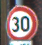

In [20]:
# Visualize test image
img = Image.open(test_path + '/00001.png')
img

In [21]:
# Original label
print("Original label : ",all_lables[y_test[1]])

Original label :  Speed limit (30km/h)


In [22]:
# Predicted label
print("Predicted label : ",all_lables[y_pred[1]])

TypeError: only integer scalar arrays can be converted to a scalar index